In [2]:
pip install pandas_datareader

In [3]:
pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 23.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import datetime
from dtaidistance import clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from dtaidistance import dtw
symbols = ['DEXUSEU', 'DEXJPUS', 'DEXKOUS', 'DEXMAUS', 'DEXCHUS' , 'DEXUSUK', 'DEXTHUS', 'DEXSZUS']
start = datetime.datetime(2015, 12, 1)
end = datetime.datetime(2024, 12, 1)
df = web.DataReader(symbols, 'fred', start, end)

In [5]:
print(df.head())
print(df.tail())
print(len(df))

            DEXUSEU  DEXJPUS  DEXKOUS  DEXMAUS  DEXCHUS  DEXUSUK  DEXTHUS  \
DATE                                                                        
2015-12-01   1.0620   122.88  1149.39    4.242   6.3883   1.5074    35.75   
2015-12-02   1.0573   123.52  1149.39    4.242   6.3883   1.4927    35.75   
2015-12-03   1.0902   123.06  1149.39    4.242   6.3883   1.5088    35.75   
2015-12-04   1.0884   123.10  1149.39    4.242   6.3883   1.5100    35.75   
2015-12-07   1.0840   123.31  1172.68    4.212   6.4081   1.5076    35.89   

            DEXSZUS  
DATE                 
2015-12-01   1.0296  
2015-12-02   1.0274  
2015-12-03   0.9996  
2015-12-04   0.9986  
2015-12-07   1.0026  
            DEXUSEU  DEXJPUS  DEXKOUS  DEXMAUS  DEXCHUS  DEXUSUK  DEXTHUS  \
DATE                                                                        
2024-11-25   1.0478   154.29  1401.03   4.4483   7.2395   1.2554    34.66   
2024-11-26   1.0481   153.49  1396.69   4.4555   7.2520   1.2547    34.71  

На изображении представлены временные ряды с валютными курсами по различным странам за два разных периода времени: декабрь 2015 года и ноябрь 2024 года. Данные сгруппированы по кодам валютных курсов, начиная с обозначения DEX, за которыми следует код страны. Расшифровка некоторых обозначений:

 DEXUSEU — курс доллара США к евро

 DEXJPUS — курс иены к доллару США

 DEXKOUS — курс воны к доллару США

 DEXMAUS — курс австралийского доллара к доллару США

 DEXCHUS — курс юаня к доллару США

 DEXUSUK — курс доллара США к фунту стерлингов

 DEXTHUS — курс бата к доллару США

 DEXSZUS — курс франка к доллару США

In [6]:
print(len(df.columns))

8


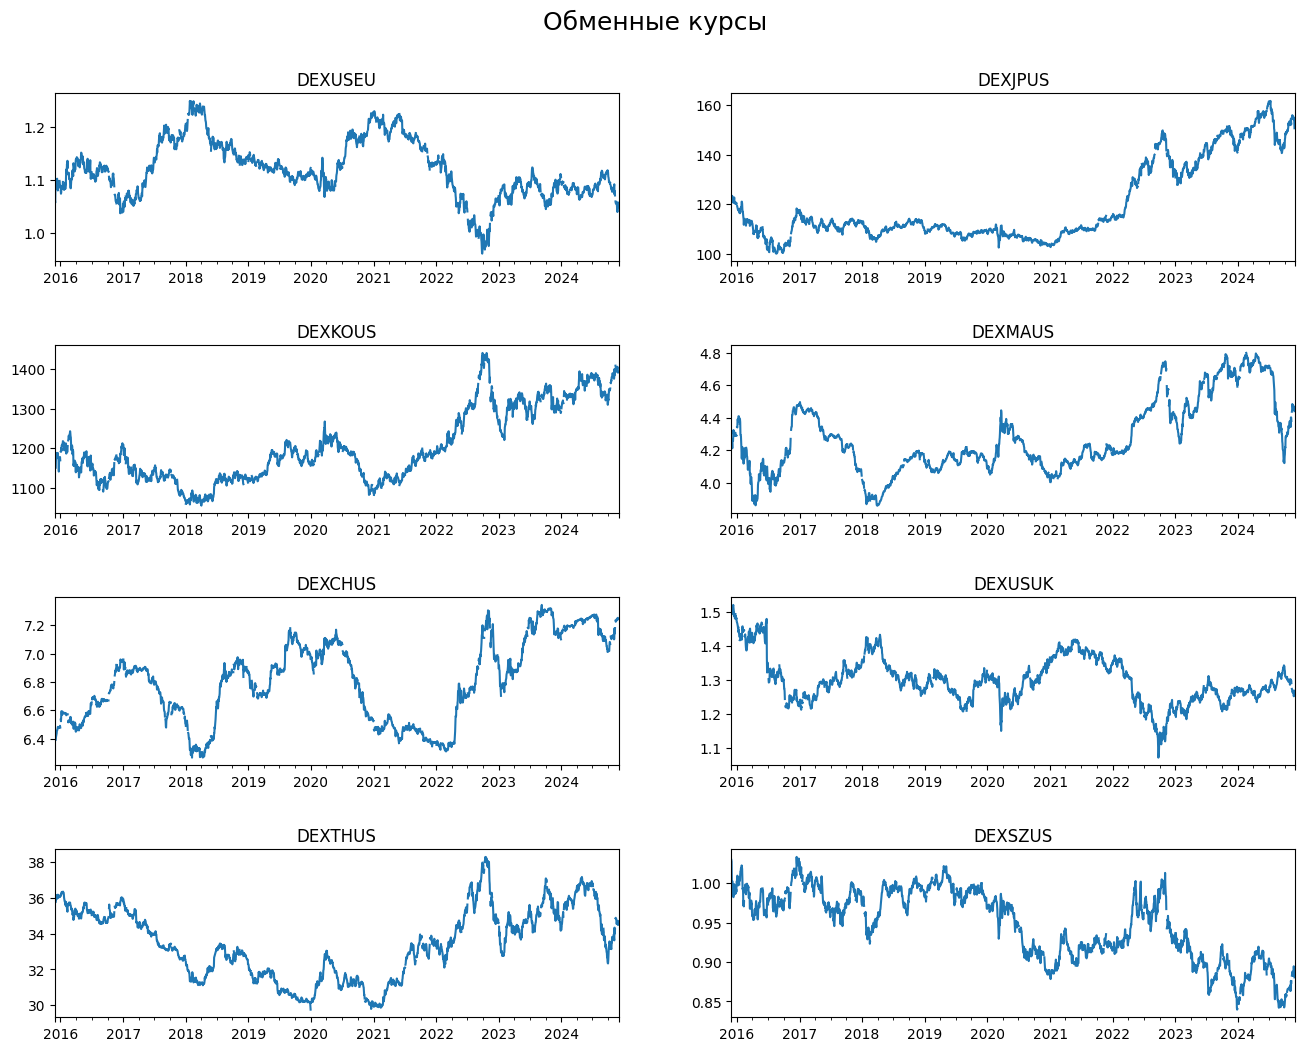

In [7]:
import matplotlib.pyplot as plt
df_melt = df.melt(ignore_index=False, var_name="symbol", value_name="exch_rate")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16,12))
plt.subplots_adjust(hspace=0.5)
fig.suptitle("Обменные курсы", fontsize=18, y=0.95)
for symbol, ax in zip(symbols, axes.ravel()):
    df_melt[df_melt['symbol'] == symbol].plot(ax=ax)
    ax.set_title(symbol.upper())
    ax.get_legend().remove()
    ax.set_xlabel("")
plt.show()

Код генерирует графики, отображающие динамику обменных курсов восьми валют по отношению к доллару США.  На каждом из восьми графиков (размещенных на сетке 4x2) показан временной ряд значений обменного курса конкретной валюты за период с 2015 по 2024 год.

По оси X отложена временная шкала, по оси Y — значение обменного курса. Название каждого графика соответствует коду валютной пары (например, DEXUSEU для евро-доллар). Легенда убрана для большей наглядности графиков.

Анализ графиков позволяет визуально оценить тенденции изменения обменных курсов каждой валюты за указанный период:  рост, падение, периоды волатильности и т.д.  Сравнивая графики между собой, можно выявить корреляции или различия в динамике курсов разных валют.


In [8]:
list1 = [0, 1, 2, 3, 6] #валюты с базой $1
list2 = [4, 5] #валюты с $1 в числителе
df_core = pd.DataFrame(columns=symbols)
#Для валют с $1 в знаменателе поделим курс на значения DEXSZUS
for i in list1:
    df_core.iloc[:,i] = df.iloc[:,i].div(df.iloc[:,7], axis=0)
#Для валют с $1 в числителе, поделим обращенное значение на DEXSZUS
for j in list2:
    df_core.iloc[:,j] = df.iloc[:,j].rdiv(1).div(df.iloc[:,7], axis=0)
#Для курса доллара, поделим $1 на ставку DEXSZUS
df_core.iloc[:,7] = df.iloc[:,7].rdiv(1)

In [9]:
df_core.columns = ['EUR', 'YEN', 'WON', 'MYR', 'CNY', 'GBP', 'THB', 'USD']
df_core = df_core.add_suffix('_SFR')

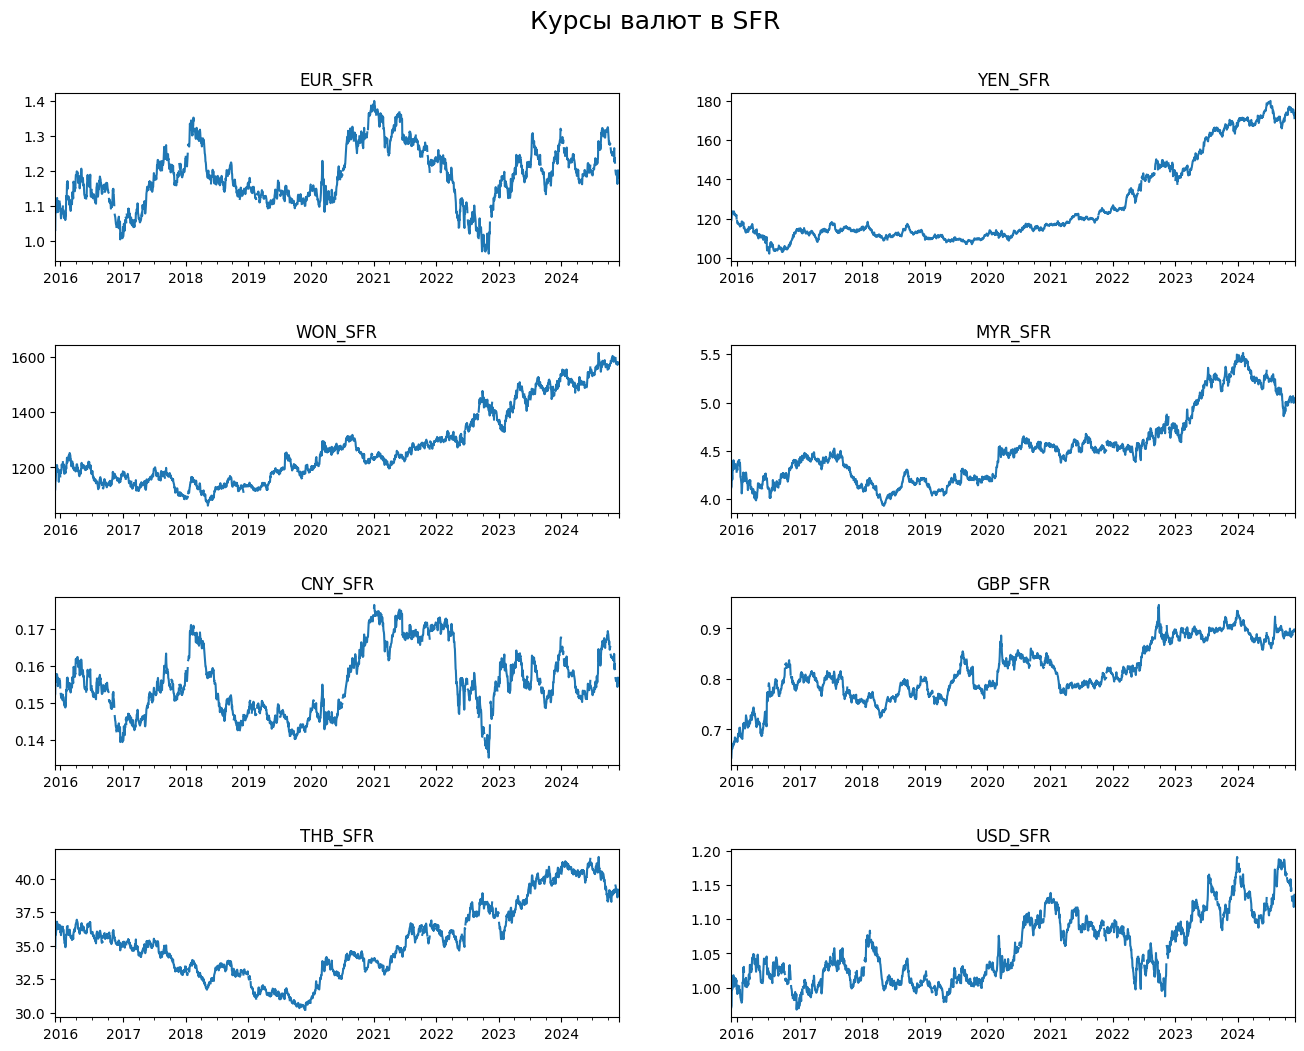

In [10]:
# Add the import statement at the beginning of your code
import matplotlib.pyplot as plt

#Изобразим ряды динамики режимов валют в раскладке 2х4
df_core_melt = df_core.melt(ignore_index=False, var_name="symbol", value_name="sfr_rate")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16,12))
plt.subplots_adjust(hspace=0.5)
fig.suptitle("Курсы валют в SFR", fontsize=18, y=0.95)
for symbol, ax in zip(df_core.columns, axes.ravel()):
    df_core_melt[df_core_melt['symbol'] == symbol].plot(ax=ax)
    ax.set_title(symbol.upper())
    ax.get_legend().remove()
    ax.set_xlabel("")
plt.show()

На изображении представлены линейные графики валютных курсов по отношению к швейцарскому франку (SFR) за период с 2016 по 2024 год. Каждый график показывает динамику определённой валюты.

<ipython-input-11-0035be4dd127>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_core_log = np.log(df_core.fillna(method='ffill')).diff().dropna()
<ipython-input-11-0035be4dd127>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_core_log = np.log(df_core.fillna(method='ffill')).diff().dropna()


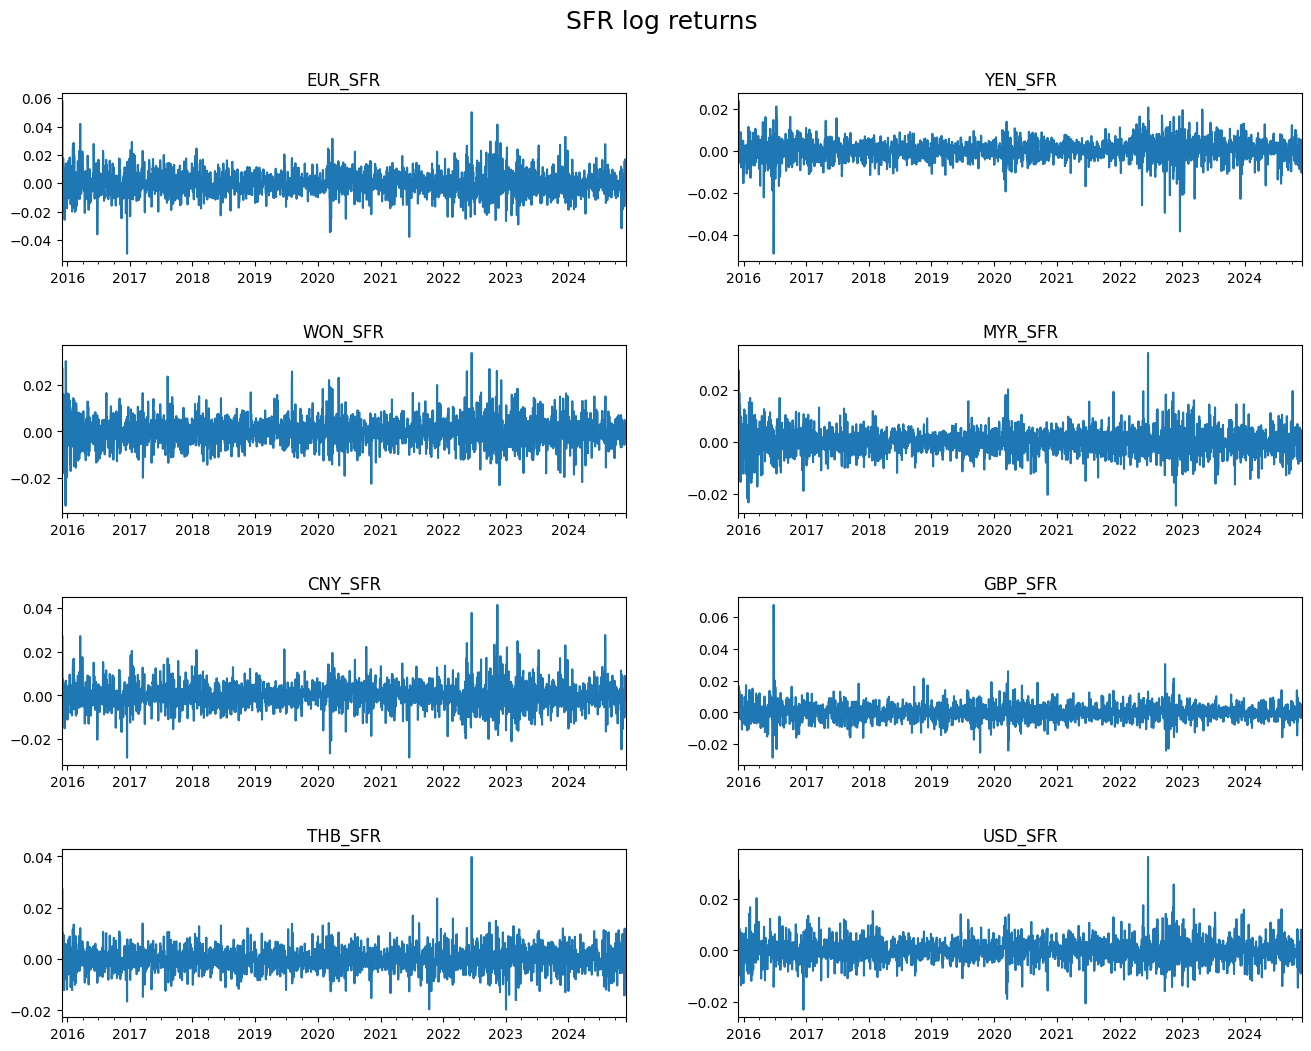

In [11]:
df_core_log = np.log(df_core.fillna(method='ffill')).diff().dropna()
df_core_log_melt = df_core_log.melt(ignore_index=False, var_name="symbol", value_name="exch_rate")
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16,12))
plt.subplots_adjust(hspace=0.5)
fig.suptitle("SFR log returns", fontsize=18, y=0.95)
for symbol, ax in zip(df_core_log.columns, axes.ravel()):
    df_core_log_melt[df_core_log_melt['symbol'] == symbol].plot(ax=ax)
    ax.set_title(symbol.upper())
    ax.get_legend().remove()
    ax.set_xlabel("")
plt.show()

EUR_SFR — сравнительно высокая волатильность, особенно в 2022–2023 гг. Есть единичные выбросы до +6% и -4%.

YEN_SFR — умеренная волатильность, резкий отрицательный скачок около 2016 года.

WON_SFR — умеренные колебания, небольшое увеличение волатильности в 2022–2023 гг.

MYR_SFR — стабильный ряд, но с редкими положительными и отрицательными всплесками.

CNY_SFR — низкая волатильность, но наблюдаются единичные импульсы роста.

GBP_SFR — резко выраженный скачок вверх в начале, далее — спокойное поведение.

THB_SFR — умеренная волатильность, особенно с 2021 года.

USD_SFR — в целом стабильно, но в 2022 и 2023 есть заметные скачки.

In [12]:
pip install --force-reinstall --no-cache-dir dtaidistance[speedup]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 168.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: dtaidistance
    Found existing installation: dtaidistance 2.3.13
    Uninstalling dtaidistance-2.3.13:
      Successfully uninstalled dtaidistance-2.3.13
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.


In [13]:
pip install cython

In [14]:
from dtaidistance import dtw
dtw.use_c = False  # Отключает C-ускорения

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

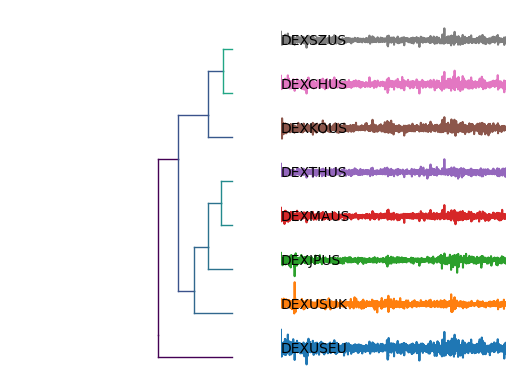

In [15]:
ds = dtw.distance_matrix_fast(np.asarray(df_core_log)) #метод LinkageTree
model = clustering.LinkageTree(dtw.distance_matrix_fast, {})
cluster_idx = model.fit(np.asarray(df_core_log.T))
mylabels = list(symbols)
model.plot(cluster_idx, show_ts_label=lambda idx: mylabels[idx])
plt.show()


DEXUSEU, DEXUSUK и DEXJPUS находятся в одной ветви — значит, их колебания схожи.

DEXSZUS и DEXCHUS также сгруппированы — они демонстрируют близкие модели поведения.

DEXKOUS и DEXTHUS образуют отдельную пару — имеют более высокую волатильность или сходную динамику по азиатским валютам.

DEXMAUS отделён от остальных — поведение этого валютного курса менее похоже на другие.

In [16]:
pip install scikit-learn

In [17]:
!pip install --upgrade numpy
!pip install --upgrade scikit-learn
!pip install --upgrade tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 25.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


In [18]:
# Create a new virtual environment (optional but recommended)
!python3 -m venv myenv
!source myenv/bin/activate

# Install the required libraries
!pip install numpy pandas pandas_datareader dtaidistance tslearn matplotlib statsmodels cython

Error: Command '['/content/myenv/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
/bin/bash: line 1: myenv/bin/activate: No such file or directory


In [19]:
import numpy as np
print(np.__version__)  # Print the NumPy version
np.array([1, 2, 3])   # Create a simple NumPy array

2.0.2


array([1, 2, 3])

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7f7877b33ba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error
Exception ignored on calling ctypes callback function: <functio

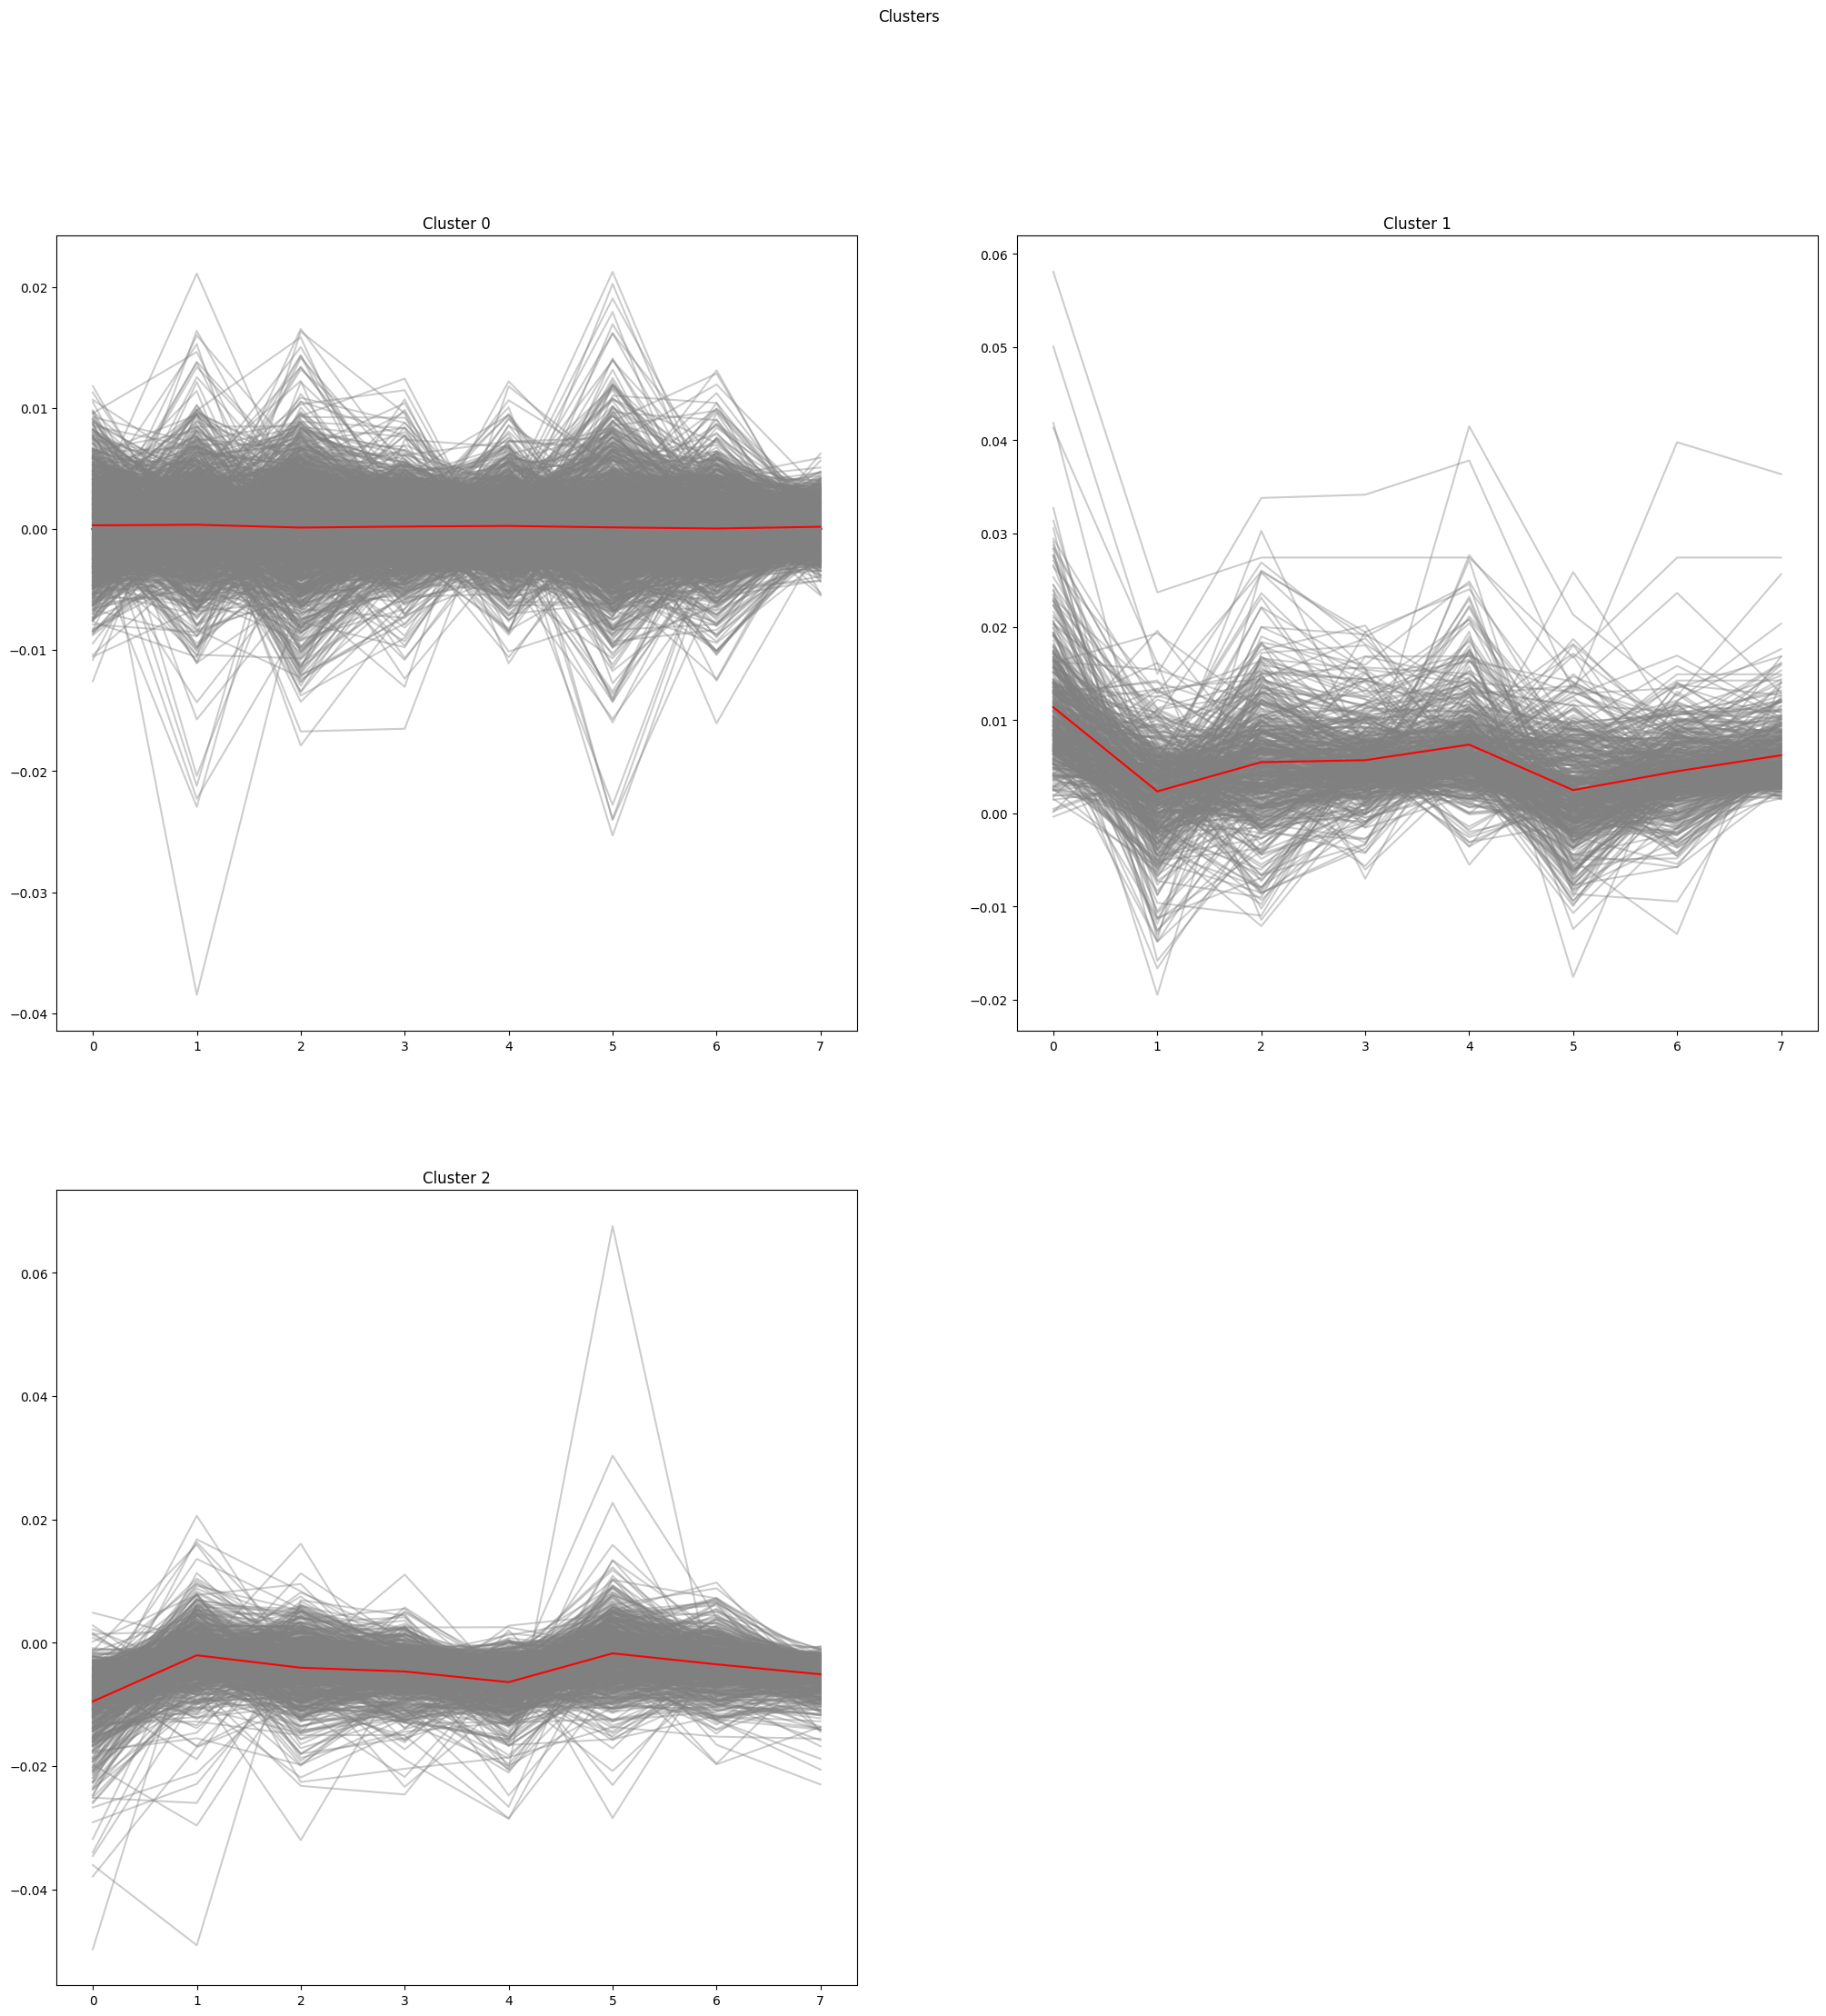

In [20]:
import math
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Initialize KMeans with the desired number of clusters
km = KMeans(n_clusters=3)  # You can change the number of clusters as needed

labels = km.fit_predict(np.asarray(df_core_log))

# Количество кластеров (уникальных меток) — это количество элементов в set(labels)
num_clusters = len(set(labels))

# Рассчитываем количество подграфиков в зависимости от числа кластеров
plot_count = math.ceil(math.sqrt(num_clusters))

fig, axs = plt.subplots(plot_count, plot_count, figsize=(25, 25))
fig.suptitle('Clusters')

# Преобразуем axs в одномерный массив для удобства индексации
axs = axs.ravel()

# Для каждого кластера строим все ряды внутри самого кластера с этой меткой
for i, label in enumerate(set(labels)):
    cluster = []
    for j in range(len(labels)):
        if labels[j] == label:
            axs[i].plot(np.asarray(df_core_log)[j], c="gray", alpha=0.4)
            cluster.append(np.asarray(df_core_log)[j])
    if len(cluster) > 0:
        axs[i].plot(np.average(np.vstack(cluster), axis=0), c="red")
    axs[i].set_title("Cluster " + str(label))

# Убираем пустые графики, если количество кластеров меньше количества подграфиков
for i in range(num_clusters, len(axs)):
    axs[i].axis('off')  # Выключаем отображение пустых подграфиков

plt.show()

Cluster 0

Средняя линия (красная) показывает отрицательную доходность, особенно на отрезке 2–4.
Есть некоторые выбросы вверх до +0.07, что говорит о неустойчивости в части рядов.
Общая динамика: слабый, но стабильный спад с небольшой волатильностью.

Cluster 1

Наиболее "плотный" кластер.
Красная линия практически плоская (вокруг 0), указывая на нейтральное среднее поведение.
Серые линии распределены симметрично, с умеренной амплитудой (от -0.02 до +0.02), и чёткой структурой "волнообразного" движения.
Можно интерпретировать как кластер стабильных рядов без выраженного тренда.

Cluster 2

Красная линия показывает положительную доходность в начале, затем плавное снижение и стабилизацию.
Серые линии распределены шире, чем в кластере 1, но не такие шумные, как в кластере 0.
Характерно умеренное положительное движение в начале, после чего поведение выравнивается.

In [21]:
import statsmodels.formula.api as smf
model_period1 = smf.ols("EUR_SFR~USD_SFR+YEN_SFR+CNY_SFR+GBP_SFR", df_core_log[:'2021-06-30']).fit()
model_period1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                EUR_SFR   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     4239.
Date:                Wed, 26 Mar 2025   Prob (F-statistic):               0.00
Time:                        10:52:23   Log-Likelihood:                 6756.5
No. Observations:                1456   AIC:                        -1.350e+04
Df Residuals:                    1451   BIC:                        -1.348e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.356e-05   6.13e-05      0.547      0.584   -8.68e-05       0.000
USD_SFR        1.6395      0.036     45.175      0.000       1.568       1.711
YEN_SFR        0.0027      0.014      0.191      0.849      -0.025       0.030
CNY_SFR        0.2163      0.027      8.050      0.000       0.164       0.269
GBP_SFR       -0.1467      0.011    -12.842      0.000      -0.169      -0.124
==============================================================================
Omnibus:                       51.187   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              133.144
Skew:                           0.086   Prob(JB):                     1.23e-29
Kurtosis:                       4.471   Cond. No.                         723.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

N = 1456 наблюдений.

R² = 0.921 — модель объясняет 92.1% дисперсии EUR_SFR.

F-statistic = 4239.0, p-value = 0.000 — модель значима в целом.



In [22]:
model_period2 = smf.ols("EUR_SFR ~ USD_SFR + YEN_SFR + CNY_SFR + GBP_SFR", df_core_log['2021-07-01':'2021-12-31']).fit()
model_period2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                EUR_SFR   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     413.8
Date:                Wed, 26 Mar 2025   Prob (F-statistic):           8.62e-72
Time:                        10:52:31   Log-Likelihood:                 657.32
No. Observations:                 132   AIC:                            -1305.
Df Residuals:                     127   BIC:                            -1290.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0003      0.000     -2.295      0.023      -0.001   -4.72e-05
USD_SFR        1.7377      0.124     13.961      0.000       1.491       1.984
YEN_SFR       -0.0562      0.053     -1.070      0.287      -0.160       0.048
CNY_SFR        0.0524      0.097      0.542      0.589      -0.139       0.244
GBP_SFR       -0.2255      0.044     -5.113      0.000      -0.313      -0.138
==============================================================================
Omnibus:                        8.605   Durbin-Watson:                   2.255
Prob(Omnibus):                  0.014   Jarque-Bera (JB):               11.053
Skew:                          -0.379   Prob(JB):                      0.00398
Kurtosis:                       4.198   Cond. No.                     1.05e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

N = 132 наблюдения.

R² = 0.929 — чуть выше, чем в первой модели (но и объём данных меньше).

F-statistic = 413.8, p < 1e-71 — модель высокозначима.

Выводы:

Во всех моделях наиболее сильное влияние на курс EUR/SFR оказывает курс USD/SFR — рост доллара к франку приводит к росту евро к франку.

Также наблюдается устойчивое отрицательное влияние со стороны GBP/SFR — укрепление фунта уменьшает курс евро.

Курс иены (YEN_SFR) не оказывает статистически значимого влияния в обеих моделях.

Курс юаня (CNY_SFR) значим только в полной выборке, но слаб и неустойчив.

In [23]:
formula = "EUR_SFR ~ USD_SFR + YEN_SFR + CNY_SFR + GBP_SFR"

years_list = ['2016', '2017', '2018', '2019', '2020', '2021']

aar = []

for i in range(len(years_list)):
 model = smf.ols(formula, df_core_log.loc[years_list[i]]).fit()
 model.summary()
 aar.append(round(math.exp(252*np.log(1+model.params[0]))-1, 3))
 print('Среднегодовой темп роста к имплицитной корзине: ' + str(aar[i]))


Среднегодовой темп роста к имплицитной корзине: 0.022
Среднегодовой темп роста к имплицитной корзине: 0.069
Среднегодовой темп роста к имплицитной корзине: -0.01
Среднегодовой темп роста к имплицитной корзине: -0.032
Среднегодовой темп роста к имплицитной корзине: 0.004
Среднегодовой темп роста к имплицитной корзине: -0.049


<ipython-input-23-a9305730072f>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  aar.append(round(math.exp(252*np.log(1+model.params[0]))-1, 3))
<ipython-input-23-a9305730072f>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  aar.append(round(math.exp(252*np.log(1+model.params[0]))-1, 3))
<ipython-input-23-a9305730072f>:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  aar.append(round(math.exp(252*np.log(1+model.params[0]))-1, 3)

[0.022, 0.069, -0.01, -0.032, 0.004, -0.049]


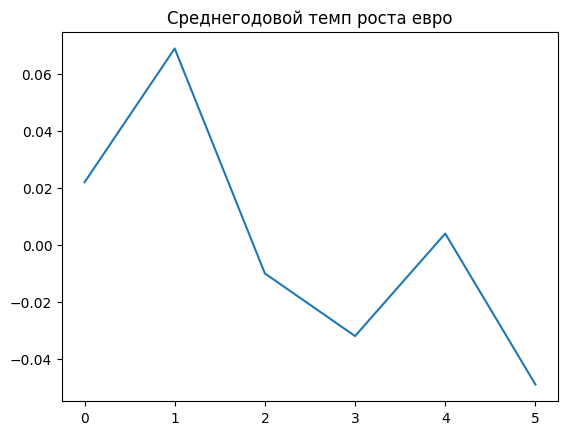

In [24]:
print(aar)

plt.plot(aar)
plt.title("Среднегодовой темп роста евро")
plt.show()


Тренд нестабильный: после периода уверенного роста в начале (особенно в год 1), курс евро демонстрирует чередование падений и слабых подъёмов.
Максимум роста — на интервале 1 (около +6.9%).
Минимум — интервал 5 (падение ~–4.9%).

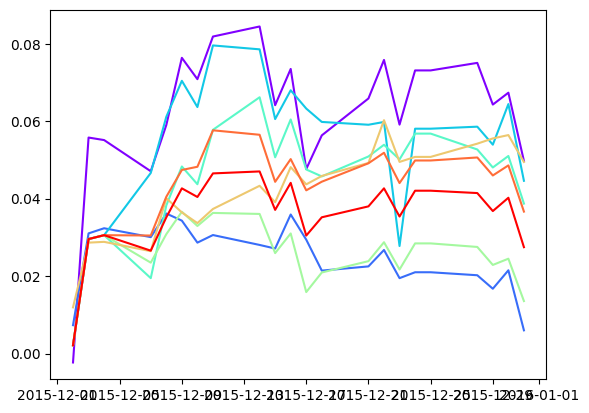

In [25]:
colors = iter(plt.cm.rainbow(np.linspace(0, 1, len(symbols))))
for i in df_core_log.columns:
 plt.plot(np.cumsum(df_core_log.loc['2015'][i]), color=next(colors))

plt.show()


Все валюты стартуют с нуля, что логично при использовании cumsum().
В течение месяца большинство валют показали положительный кумулятивный рост — от ~2% до 8%.
Некоторые — особенно фиолетовая и бирюзовая линии — показывают наибольший прирост (до 0.08 или 8%).
Несколько валют более стабильны — линии почти горизонтальны (прирост около 3–4%).

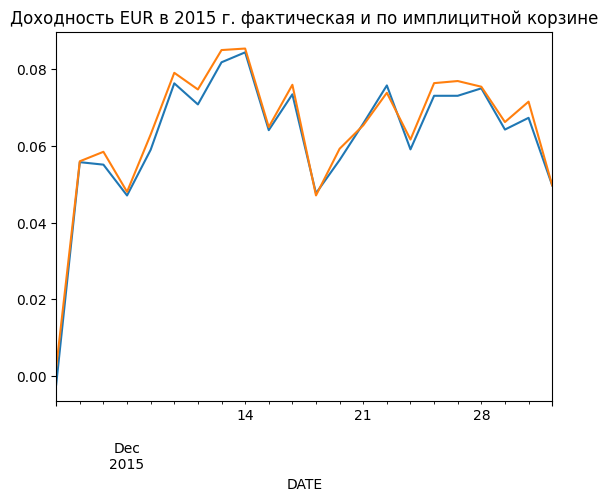

In [26]:
model_y12 = smf.ols(formula, df_core_log.loc['2015']).fit()
cny_sfr_act = df_core_log['EUR_SFR'].loc['2015']

cny_sfr_fit = cny_sfr_act - model_y12.resid

np.cumsum(cny_sfr_act).plot()
np.cumsum(cny_sfr_fit).plot()
plt.title("Доходность EUR в 2015 г. фактическая и по имплицитной корзине")
plt.show()


Модель на основе валютной корзины адекватно объясняет фактическую динамику курса евро в декабре 2015.
Это говорит о высокой степени зависимости EUR от выбранных валют (USD, JPY, CNY, GBP) в краткосрочном периоде.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.tools.tools import maybe_unwrap_results
from typing import Type
import statsmodels.regression

In [28]:
style_talk = 'seaborn-talk'

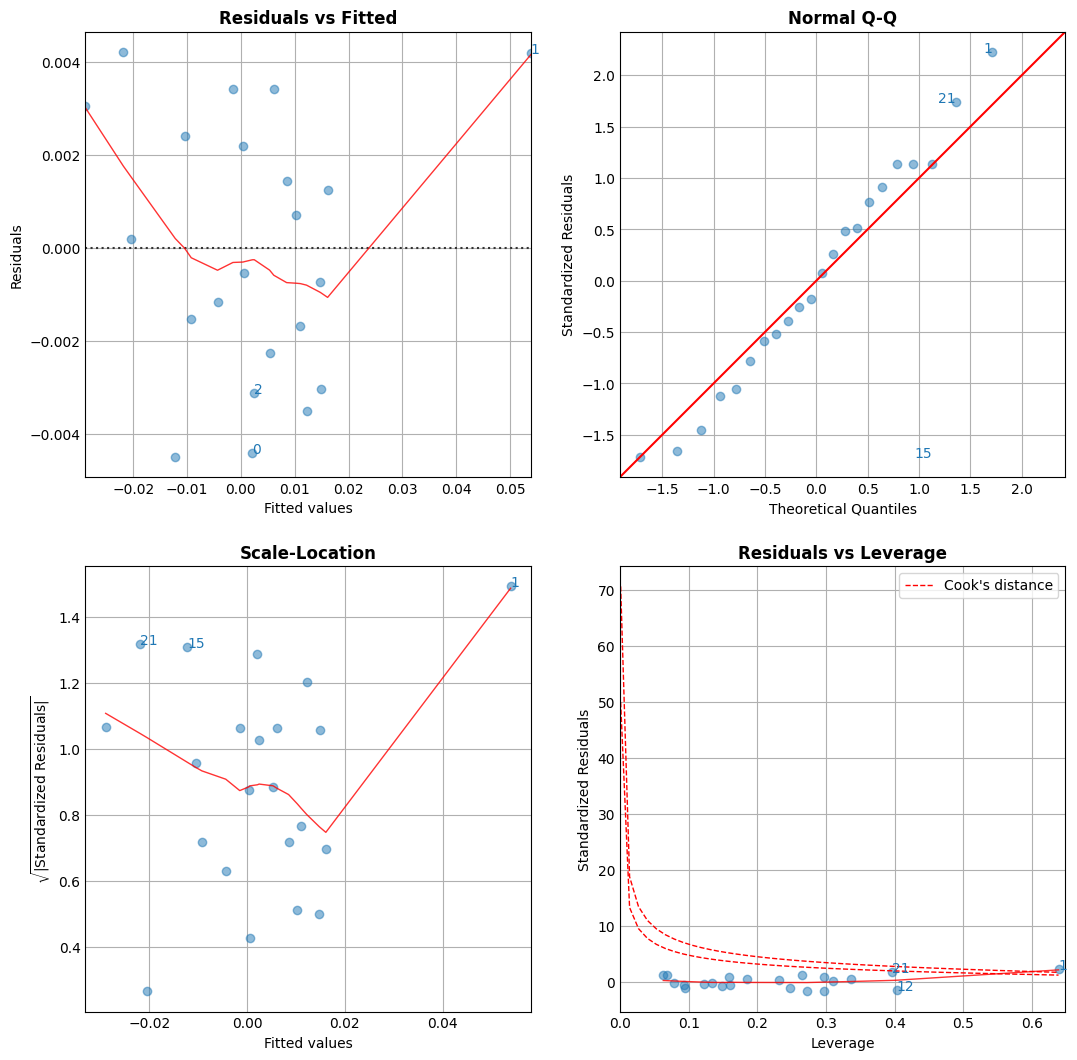

NameError: name 'sort_values' is not defined

In [29]:
class Linear_Reg_Diagnostic():
 def __init__(self,
              results: Type[statsmodels.regression.linear_model.RegressionResultsWrapper]) -> None:
  if isinstance(results, statsmodels.regression.linear_model.RegressionResultsWrapper) is False:
   raise TypeError("result must be instance of statsmodels.regression.linear_model.RegressionResultsWrapper object")
  self.results = maybe_unwrap_results(results)
  self.y_true = self.results.model.endog
  self.y_predict = self.results.fittedvalues
  self.xvar = self.results.model.exog
  self.xvar_names = self.results.model.exog_names
  self.residual = np.array(self.results.resid)
  influence = self.results.get_influence()
  self.residual_norm = influence.resid_studentized_internal
  self.leverage = influence.hat_matrix_diag
  self.cooks_distance = influence.cooks_distance[0]
  self.nparams = len(self.results.params)
 def __call__(self, plot_context='_mpl-gallery'):
  # print(plt.style.available)
  with plt.style.context(plot_context):
   fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
   self.residual_plot(ax=ax[0,0])
   self.qq_plot(ax=ax[0,1])
   self.scale_location_plot(ax=ax[1,0])
   self.leverage_plot(ax=ax[1,1])
   plt.show()
  self.vif_table()
  return fig, ax
 def residual_plot(self, ax=None):
   if ax is None:
    fig, ax = plt.subplots()
   sns.residplot(x=self.y_predict, y=self.residual, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax)
  # annotations
   residual_abs = np.abs(self.residual)
   abs_resid = np.flip(np.sort(residual_abs))
   abs_resid_top_3 = abs_resid[:3]
   for i, _ in enumerate(abs_resid_top_3):
    ax.annotate(i, xy=(self.y_predict[i], self.residual[i]), color='C3')
   ax.set_title('Residuals vs Fitted', fontweight="bold")
   ax.set_xlabel('Fitted values')
   ax.set_ylabel('Residuals')
   return ax
 def qq_plot(self, ax=None):
  if ax is None:
   fig, ax = plt.subplots()
  QQ = ProbPlot(self.residual_norm)
  QQ.qqplot(line='45', alpha=0.5, lw=1, ax=ax)
  # annotations
  abs_norm_resid = np.flip(np.argsort(np.abs(self.residual_norm)), 0)
  abs_norm_resid_top_3 = abs_norm_resid[:3]
  for r, i in enumerate(abs_norm_resid_top_3):
   ax.annotate(i, xy=(np.flip(QQ.theoretical_quantiles, 0)[r], self.residual_norm[i]), ha='right', color='C3')
  ax.set_title('Normal Q-Q', fontweight="bold")
  ax.set_xlabel('Theoretical Quantiles')
  ax.set_ylabel('Standardized Residuals')
  return ax
 def scale_location_plot(self, ax=None):
  if ax is None:
   fig, ax = plt.subplots()
  residual_norm_abs_sqrt = np.sqrt(np.abs(self.residual_norm))
  ax.scatter(self.y_predict, residual_norm_abs_sqrt, alpha=0.5);
  sns.regplot(x=self.y_predict, y=residual_norm_abs_sqrt,    scatter=False, ci=False, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax)
  abs_sq_norm_resid = np.flip(np.argsort(residual_norm_abs_sqrt), 0)
  abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
  for i in abs_sq_norm_resid_top_3:
   ax.annotate(i, xy=(self.y_predict[i], residual_norm_abs_sqrt[i]), color='C3')
  ax.set_title('Scale-Location', fontweight="bold")
  ax.set_xlabel('Fitted values')
  ax.set_ylabel(r'$\sqrt{|\mathrm{Standardized\ Residuals}|}$');
  return ax
 def leverage_plot(self, ax=None):
  if ax is None:
   fig, ax = plt.subplots()
  ax.scatter(
   self.leverage,
   self.residual_norm,
   alpha=0.5);
  sns.regplot(
   x=self.leverage,
   y=self.residual_norm,
   scatter=False,
   ci=False,
   lowess=True,
   line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8}, ax=ax)
  # annotations
  leverage_top_3 = np.flip(np.argsort(self.cooks_distance), 0)[:3]
  for i in leverage_top_3:
   ax.annotate(i, xy=(self.leverage[i], self.residual_norm[i]), color = 'C3')
  xtemp, ytemp = self.__cooks_dist_line(0.5) # 0.5 line
  ax.plot(xtemp, ytemp, label="Cook's distance", lw=1, ls='--', color='red')
  xtemp, ytemp = self.__cooks_dist_line(1) # 1 line
  ax.plot(xtemp, ytemp, lw=1, ls='--', color='red')
  ax.set_xlim(0, max(self.leverage)+0.01)
  ax.set_title('Residuals vs Leverage', fontweight="bold")
  ax.set_xlabel('Leverage')
  ax.set_ylabel('Standardized Residuals')
  ax.legend(loc='upper right')
  return ax
 def vif_table(self):
  vif_df = pd.DataFrame()
  vif_df["Features"] = self.xvar_names
  vif_df["VIF Factor"] = [variance_inflation_factor(self.xvar, i) for i in range(self.xvar.shape[1])]
  print(vif_df, sort_values("VIF Factor").round(2))
 def __cooks_dist_line(self, factor):
  p = self.nparams
  formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
  x = np.linspace(0.001, max(self.leverage), 50)
  y = formula(x)
  return x, y

cls = Linear_Reg_Diagnostic(model_y12)
fig, ax = cls()
plt.show()

Residuals vs Fitted:
Остатки не распределены случайно вокруг нуля — видна вогнутая форма.
Это может указывать на нарушение линейности (модель могла бы быть улучшена, например, добавлением полиномиального члена).
Также есть намёк на гетероскедастичность — разброс остатков меняется при изменении предсказанного значения.

Normal Q-Q: Основная часть точек находится вдоль линии, что говорит о приближённой нормальности остатков.
Однако на концах наблюдаются отклонения — возможны выбросы.

Scale-Location: Здесь наблюдается вогнутая форма красной линии, а также рост дисперсии при увеличении предсказанных значений.
Это свидетельствует о гетероскедастичности: разброс ошибок зависит от значений предсказаний.

Residuals vs Leverage: Точки в правом верхнем углу и выше красных линий могут быть влиятельными (особенно наблюдение №1 — оно имеет высокий leverage и значительное отклонение).
Наблюдения №21, №12 и №1 — кандидаты на проверку: возможно, выбросы или аномалии, оказывающие влияние на модель.